# Manejo de Datos Desbalanceados
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/02_eda/08_manejo_de_datos_desbalanceados.ipynb)


## Objetivos

- Comprender el problema de los datasets desbalanceados y por qué métricas como *accuracy* pueden ser engañosas en estos escenarios.
- Identificar situaciones reales donde el desbalance es común (fraude, fallas industriales, diagnóstico médico).
- Aplicar técnicas de remuestreo (*resampling*) para equilibrar datasets: Undersampling, Oversampling y SMOTE.
- Visualizar cómo estas técnicas modifican la distribución de las clases en el espacio de características.
- Comprender el enfoque alternativo de pesos de clase (*class weights*) dentro de algunos algoritmos.
- Reconocer los riesgos de *data leakage* al aplicar técnicas de remuestreo antes de la división de entrenamiento y prueba.

## Prerrequisitos

- [Conceptos Básicos de Machine Learning](../01_introduccion/01_conceptos_basicos.ipynb).
- [Detección Avanzada de Anomalías](07_deteccion_avanzada_anomalias.ipynb) *(Recomendado para entender la diferencia entre una anomalía y una clase minoritaria legítima)*.

---
## Configuración del Entorno

In [ ]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

# Detectar Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Ejecución en Google Colab. Clonando repositorio...")
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

# Importar utilidades globales
from utils.plots import setup_plot_style
setup_plot_style()

Ejecución en Google Colab. Clonando repositorio...


## 1. El Problema del Desbalance


En muchos problemas reales y críticos de ingeniería (como la detección de fraude en tarjetas de crédito, fallas en maquinaria industrial, o diagnóstico de enfermedades raras), nos encontramos con un escenario donde **lo que queremos detectar ocurre muy pocas veces**.

Imaginemos un dataset donde el 99% de las piezas fabricadas son "Sanas" y solo el 1% son "Defectuosas".
Si se crea un modelo "tonto" que simplemente prediga *siempre* "Sana", tendrá una exactitud (*Accuracy*) del 99%. Suena a un éxito rotundo, pero en realidad el modelo es **completamente inútil**, porque dejará pasar todas las piezas defectuosas a producción (que es justamente lo interesa detectar/identificar en la vida real).


> NOTA: este tipo extremos de casos suele atacarse como un problema de "detección de anomalías", lo uso de ejemplo solamente ahora. Más adelante lo vemos en detalle.


Este *notebook* se enfocará en las estrategias de **procesamiento de datos** para mitigar este efecto antes de llegar a la etapa de modelado.

## 2. Técnicas de Remuestreo (*Resampling*) a Nivel de Datos


Cuando las clases están muy desbalanceadas, el algoritmo de aprendizaje pasa la mayor parte de su tiempo "viendo" ejemplos de la clase mayoritaria, y casi no tiene la oportunidad de aprender los patrones de la clase minoritaria.

Para forzar al modelo a prestar atención a la clase minoritaria, podemos equilibrar matemáticamente el *dataset*.

Generamos un *dataset* de juguete altamente desbalanceado para visualizarlo en 2D:

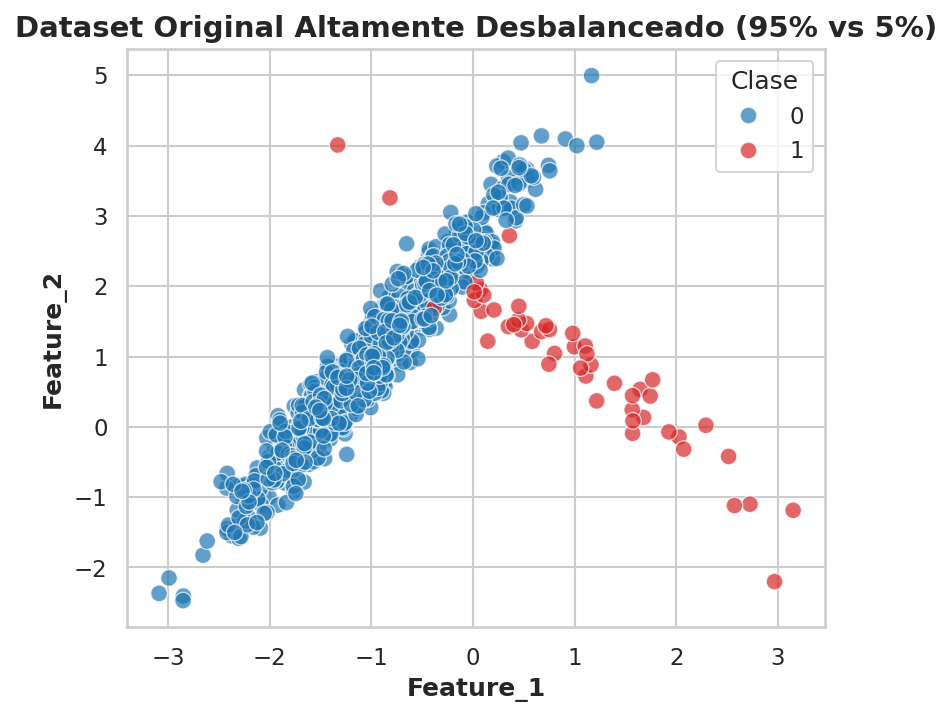

Clase 0 (Mayoritaria): 950 muestras
Clase 1 (Minoritaria): 50 muestras


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification

# Dataset desbalanceado: 95% clase 0, 5% clase 1
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.95],
    flip_y=0,
    random_state=42
)

df = pd.DataFrame({'Feature_1': X[:, 0], 'Feature_2': X[:, 1], 'Clase': y})

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='Feature_1', y='Feature_2', hue='Clase', palette=['#1f77b4', '#d62728'], alpha=0.7)
plt.title("Dataset Original Altamente Desbalanceado (95% vs 5%)")
plt.show()

print(f"Clase 0 (Mayoritaria): {sum(y==0)} muestras")
print(f"Clase 1 (Minoritaria): {sum(y==1)} muestras")

### 2.1 Submuestreo Aleatorio (*Random Undersampling*)



El enfoque más simple: **descartar datos** de la clase mayoritaria hasta igualar la cantidad de la clase minoritaria.



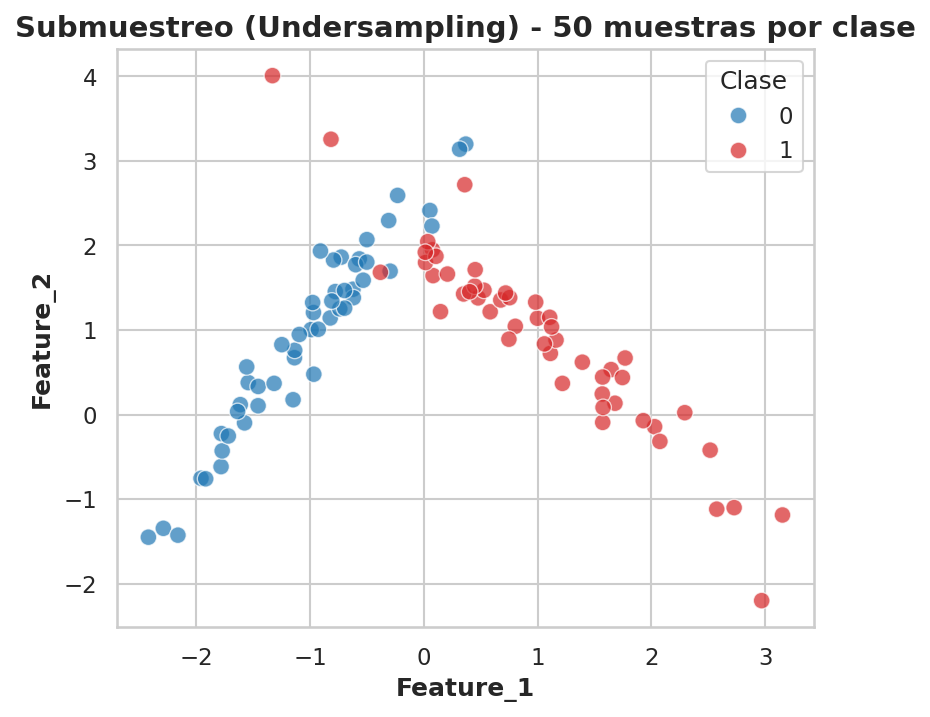

Tras Submuestreo - Clase 0: 50, Clase 1: 50


In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)

df_rus = pd.DataFrame({'Feature_1': X_rus[:, 0], 'Feature_2': X_rus[:, 1], 'Clase': y_rus})

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df_rus, x='Feature_1', y='Feature_2', hue='Clase', palette=['#1f77b4', '#d62728'], alpha=0.7)
plt.title("Submuestreo (Undersampling) - 50 muestras por clase")
plt.show()

print(f"Tras Submuestreo - Clase 0: {sum(y_rus==0)}, Clase 1: {sum(y_rus==1)}")


**Análisis de Ingeniería:**
- **Ventaja:** Reduce drásticamente el tamaño del *dataset*, acelerando el tiempo de entrenamiento de O(N^2) a milisegundos.
- **Desventaja (Fatal):** ¡Descartamos el `94%` de nuestros datos! Tirar información a la basura rara vez es buena idea en Machine Learning. Utilizarlo si se tienen millones de filas, problemas severos de RAM/procesamiento, o el problema amerita trabajar con una muestra pequeña y representativa de datos.

### 2.2 Sobremuestreo Aleatorio (*Random Oversampling*)



El enfoque contrario: **duplicar** las muestras existentes de la clase minoritaria hasta igualar a la mayoritaria.

**Análisis de Ingeniería:**
- **Ventaja:** No perdemos información de la clase mayoritaria.
- **Desventaja:** Al clonar puntos exactamente iguales, estamos forzando al modelo a aprenderse de memoria esos puntos específicos. Esto lleva directo al **Sobreajuste (*Overfitting*)** severo en los datos de entrenamiento.



### 2.3 SMOTE (*Synthetic Minority Over-sampling Technique*)



SMOTE es una técnica mucho más inteligente. En lugar de duplicar puntos ciegamente, **interpola**.
Busca un punto de la clase minoritaria, busca sus vecinos más cercanos (de la misma clase), y crea un nuevo punto artificial trazando una línea entre ellos.



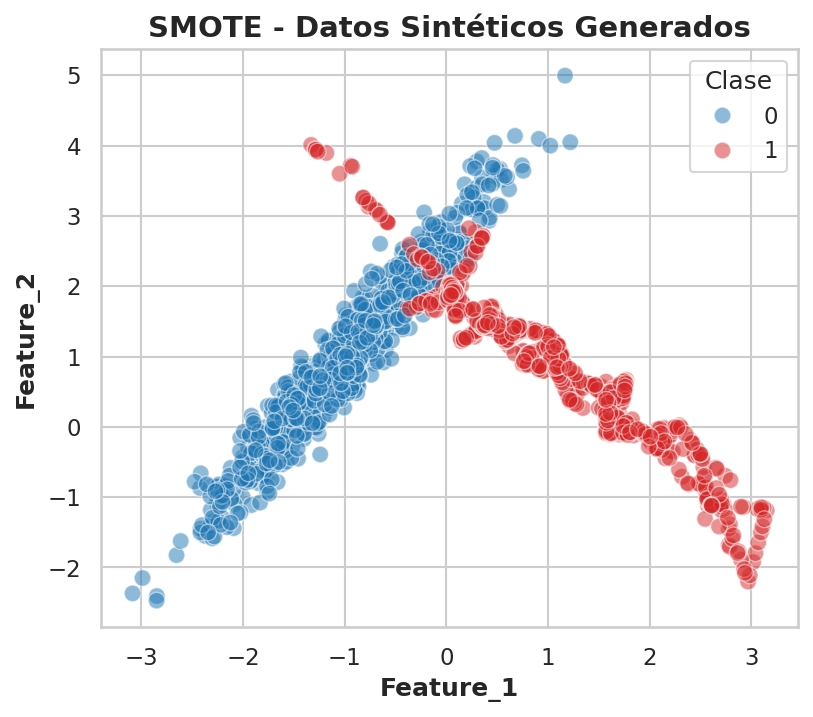

Tras SMOTE - Clase 0: 950, Clase 1: 950


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

df_smote = pd.DataFrame({'Feature_1': X_smote[:, 0], 'Feature_2': X_smote[:, 1], 'Clase': y_smote})

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df_smote, x='Feature_1', y='Feature_2', hue='Clase', palette=['#1f77b4', '#d62728'], alpha=0.5)
plt.title("SMOTE - Datos Sintéticos Generados")
plt.show()

print(f"Tras SMOTE - Clase 0: {sum(y_smote==0)}, Clase 1: {sum(y_smote==1)}")


Observar la nube roja de ahora (Clase 1). SMOTE ha "rellenado" la región donde existe la clase minoritaria creando ejemplos plausibles que no existían originalmente. Esto expande la frontera de decisión sin caer en el *overfitting* crudo de duplicar filas.



## 3. La Alternativa: Pesos de Clase (*Class Weights*)


¿Debemos modificar siempre nuestro *dataset* con SMOTE? No necesariamente.
En lugar de alterar los datos con matemáticas, la mayoría de los algoritmos de Scikit-Learn (como Random Forest o Regresión Logística) ofrecen un parámetro llamado `class_weight='balanced'`.

Este enfoque actúa sobre la función de costo (*Loss Function*) del algoritmo durante el entrenamiento. Le dice al modelo matemáticamente:
> *"Si te equivocás clasificando a la clase minoritaria (Defecto/Enfermedad), la penalización será 100 veces mayor que si te equivocás con la clase normal"*.

Esto se abordará en profundidad (junto con el uso correcto de *Pipelines*) en el **Capítulo 3** (con lo referente a los modelos de *machine learning*).

> ⚠️ **Advertencia Crítica:** Si se aplica SMOTE (u otra técnica de sobremuestreo), **NUNCA** se debe de hacer antes del `train_test_split` (subdivisión de sets para entrenar y testear). Si se aplica SMOTE a todo el *dataset*, se crean datos sintéticos en la zona de *test* pero basados en los datos de entrenamiento (*Data Leakage* masivo), y las métricas de validación serán falsamente altas (incluso este error aparece en muchos *"papers científicos"*).

## Referencias


1. [SMOTE: Synthetic Minority Over-sampling Technique](https://arxiv.org/abs/1106.1813) - *Paper*
2. [imbalanced-learn](https://imbalanced-learn.org/stable/) — biblioteca especializada en técnicas de balanceo de *datasets*.

## Conexiones y Próximos Pasos
- ➡️ **Siguiente:** ¡Felicidades! Has completado el bloque de Análisis Exploratorio y Preprocesamiento. Estás listo para el **Capítulo 3**, donde conectamos todo esto en flujos de trabajo profesionales (Pipelines) y entrenamos nuestros primeros modelos predictivos. Conviene comenzar con: - [Introducción a la Clasificación y Fronteras de Decisión](../03_machine_learning/01_introduccion_clasificacion.ipynb)


## Entorno de Ejecución


In [ ]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
imblearn,0.14.1
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
